# Análise de Métricas de Training

Este notebook analisa as métricas de training loss para diferentes versões do modelo. A estrutura é modular para facilitar a adição de novas versões.

## Estrutura do Notebook:
1. **Utils** - Funções utilitárias reutilizáveis
2. **v1.1.0** - Análise da versão 1.1.0
3. **v1.1.1** - Análise da versão 1.1.1
4. **Template** - Template para adicionar novas versões


In [1]:
# Utils

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Configuração de estilo
plt.style.use("default")
# sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [2]:
def load_metrics(file_path):
    df = pd.read_csv(file_path)
    return df


def calculate_metrics_summary(df, loss_column="Training Loss"):
    loss_values = df[loss_column]

    summary = {
        "Valor Inicial": loss_values.iloc[0],
        "Valor Final": loss_values.iloc[-1],
        "Mínimo": loss_values.min(),
        "Máximo": loss_values.max(),
        "Média": loss_values.mean(),
        "Mediana": loss_values.median(),
        "Desvio Padrão": loss_values.std(),
        "Redução Total": loss_values.iloc[0] - loss_values.iloc[-1],
        "Redução %": (
            (loss_values.iloc[0] - loss_values.iloc[-1]) / loss_values.iloc[0]
        )
        * 100,
    }

    return summary


def plot_training_metrics(
    df, version_name, loss_column="Training Loss", step_column="Step"
):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico 1: Training Loss ao longo do tempo
    ax1.plot(
        df[step_column],
        df[loss_column],
        "o-",
        alpha=0.7,
        linewidth=2,
        markersize=4,
        label="Training Loss",
    )

    # Média móvel
    window_size = max(3, len(df) // 10)  # Janela adaptativa
    rolling_mean = df[loss_column].rolling(window=window_size, center=True).mean()
    ax1.plot(
        df[step_column],
        rolling_mean,
        "--",
        linewidth=2,
        alpha=0.8,
        label=f"Média Móvel ({window_size} steps)",
    )

    ax1.set_xlabel("Step")
    ax1.set_ylabel("Training Loss")
    ax1.set_title(f"{version_name} - Training Loss ao Longo do Tempo")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Distribuição do Loss
    ax2.hist(df[loss_column], bins=15, alpha=0.7, edgecolor="black")
    ax2.axvline(
        df[loss_column].mean(),
        color="orange",
        linestyle="--",
        linewidth=2,
        label=f"Média: {df[loss_column].mean():.3f}",
    )
    ax2.axvline(
        df[loss_column].median(),
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Mediana: {df[loss_column].median():.3f}",
    )
    ax2.set_xlabel("Training Loss")
    ax2.set_ylabel("Frequência")
    ax2.set_title(f"{version_name} - Distribuição do Training Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def analyze_version(version_name):
    # Carregar dados
    file_path = f"metrics/{version_name}.csv"
    df = load_metrics(file_path)

    # Calcular métricas
    summary = calculate_metrics_summary(df)

    # Exibir tabela
    display_metrics_table(summary, version_name)

    # Exibir gráficos
    plot_training_metrics(df, version_name)

    return df, summary


def display_metrics_table(summary_dict, version_name):
    print(version_name)
    df_summary = pd.DataFrame(list(summary_dict.items()), columns=["Métrica", "Valor"])
    display(df_summary)

v1.1.0


,Métrica,Valor
0,Valor Inicial,4.100400
1,Valor Final,1.974200
2,Mínimo,1.974200
3,Máximo,4.100400
4,Média,2.653187
5,Mediana,2.551650
6,Desvio Padrão,0.496730
7,Redução Total,2.126200
8,Redução %,51.853478


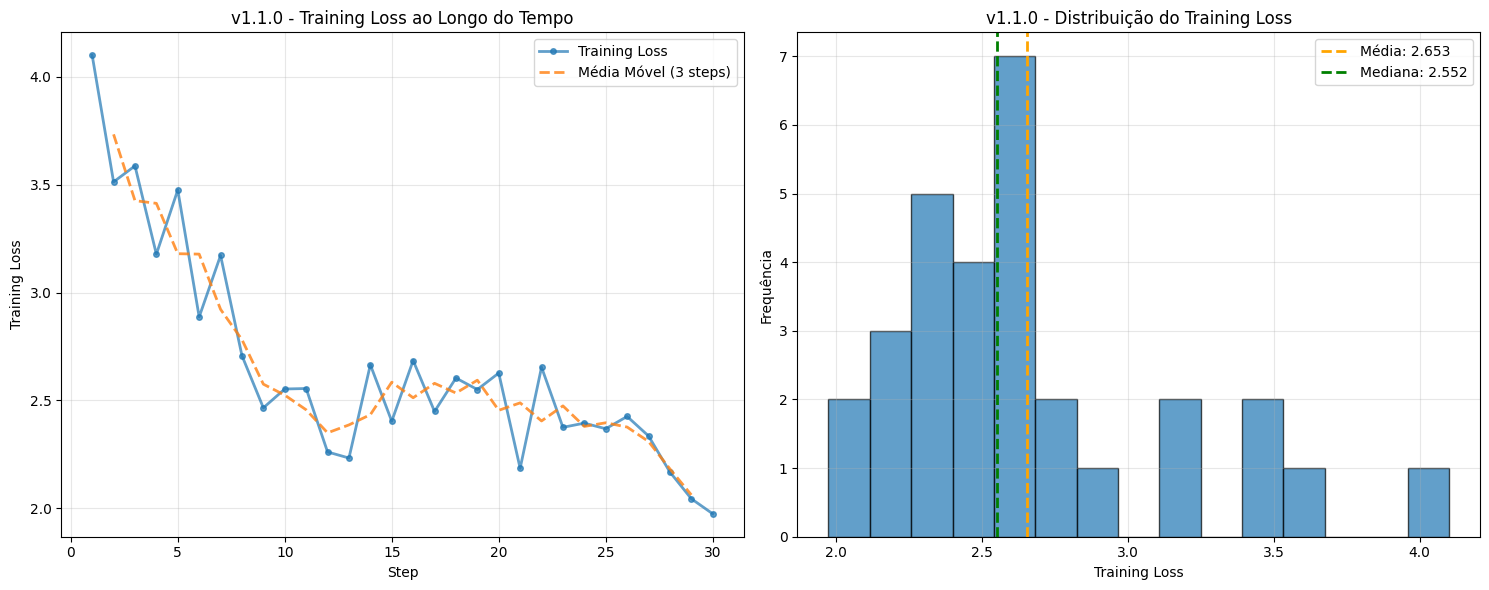

In [3]:
df_v110, summary_v110 = analyze_version("v1.1.0")


v1.2.0


,Métrica,Valor
0,Valor Inicial,4.097600
1,Valor Final,2.319000
2,Mínimo,0.661100
3,Máximo,4.097600
4,Média,2.243963
5,Mediana,2.252700
6,Desvio Padrão,0.280982
7,Redução Total,1.778600
8,Redução %,43.405896


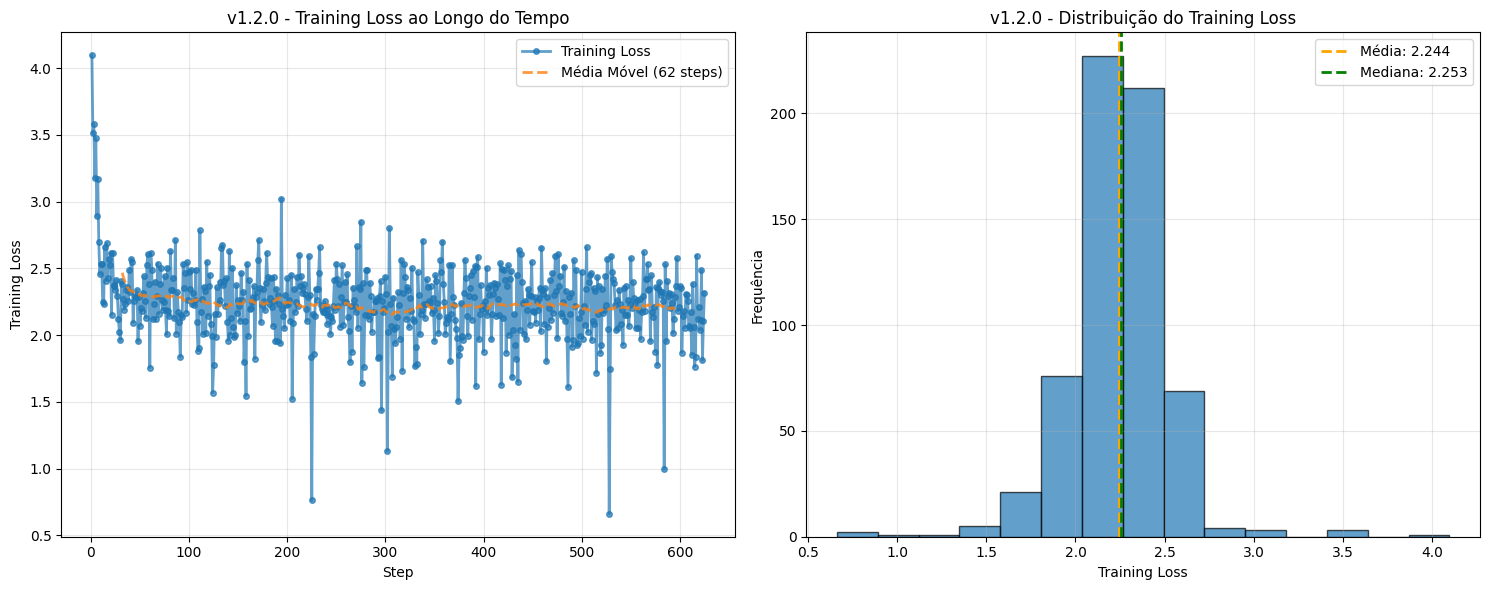

In [4]:
df_v110, summary_v110 = analyze_version("v1.2.0")


v1.3.0


,Métrica,Valor
0,Valor Inicial,3.994400
1,Valor Final,1.777200
2,Mínimo,0.820300
3,Máximo,3.994400
4,Média,1.980694
5,Mediana,1.964900
6,Desvio Padrão,0.270146
7,Redução Total,2.217200
8,Redução %,55.507711


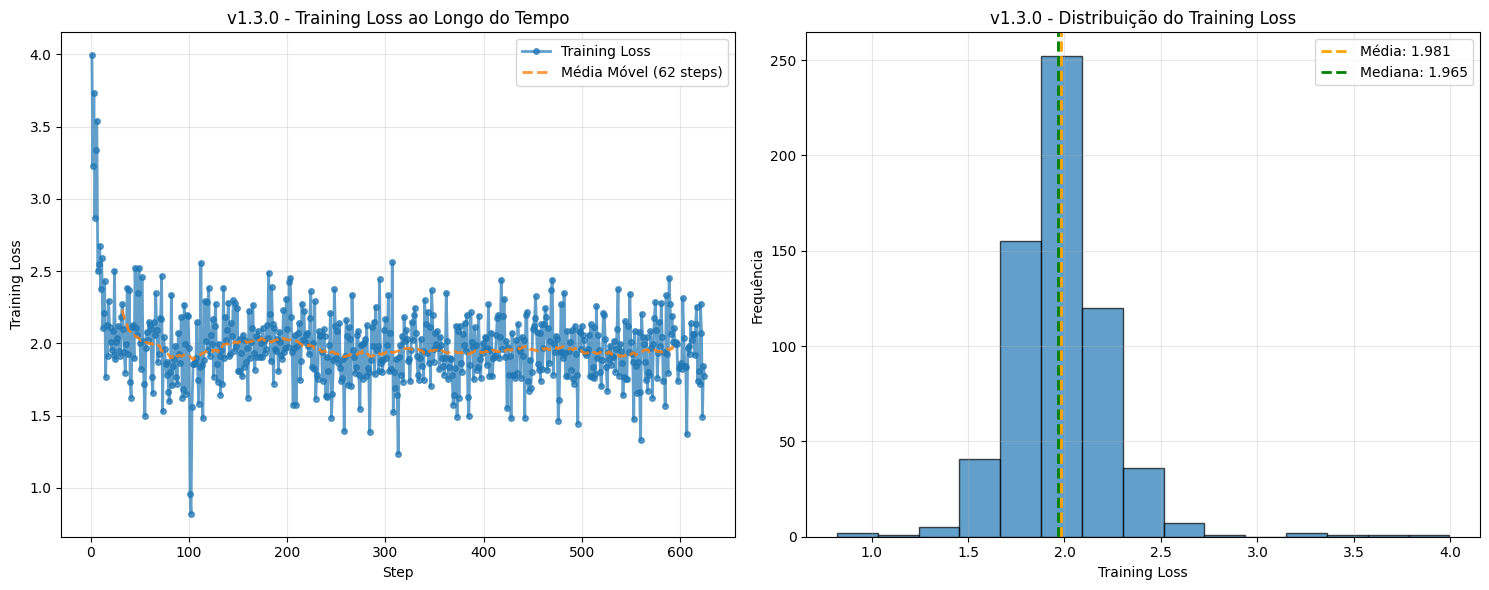

In [5]:
df_v110, summary_v110 = analyze_version("v1.3.0")


v1.4.0


,Métrica,Valor
0,Valor Inicial,3.049900
1,Valor Final,1.875600
2,Mínimo,0.539100
3,Máximo,3.883700
4,Média,1.850726
5,Mediana,1.856750
6,Desvio Padrão,0.286042
7,Redução Total,1.174300
8,Redução %,38.502902


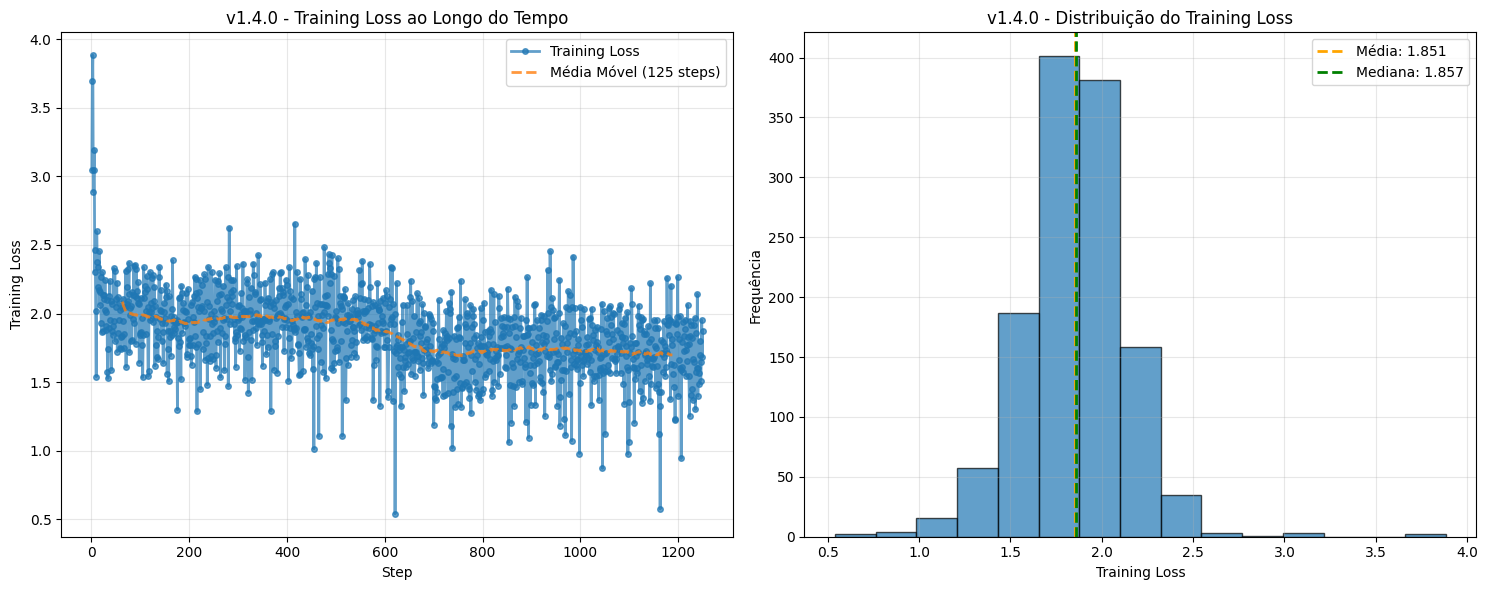

In [6]:
df_v110, summary_v110 = analyze_version("v1.4.0")
